<a href="https://colab.research.google.com/github/Hyelimee/honmandeep/blob/main/%ED%98%BC%EB%A7%8C%EB%94%A5_6%EC%A3%BC%EC%B0%A8_chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#셀프어텐션 만들기
import keras
from keras import layers

def self_attention(inputs, att_dim):
    #(n_batch, n_token, embed_dim) --> (n_batch, n_token, att_dim)
    query = layers.Dense(att_dim)(inputs)
    key = layers.Dense(att_dim)(inputs)
    value = layers.Dense(att_dim)(Inputs)

    #score: (n_batch, n_token, n_token)
    key_t = keras.ops.transpose(k, axes=(0, 2, 1))
    query_key_dot = keras.ops.matmul(query, key_t) / keras.ops.sqrt(att_dim)

    # 어텐션가중치
    score = keras.activations.softmax(query_key_dot)
    #(n_batch, n_token, att_dim)
    return keras.ops.matmul(score, value)

'''
n_batch : 배치 크기
n_token : 토큰 개수
embed_dim : 토큰 임베딩 크기
att_dim : 쿼리, 키, 값 벡터의 크기
'''

'\nn_batch : 배치 크기\nn_token : 토큰 개수\nembed_dim : 토큰 임베딩 크기\natt_dim : 쿼리, 키, 값 벡터의 크기\n'

In [2]:
#멀티헤드어텐션
import keras
from keras import layers

inputs = keras.Input(shape=(10, 20))
x = layers.MultiHeadAttention(num_heads=4, key_dim=5)(query=inputs, value=inputs)
model = keras.Model(inputs, x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 20)    │      1,680 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,680 (6.56 KB)

 Trainable params: 1,680 (6.56 KB)

 Non-trainable params: 0 (0.00 B)

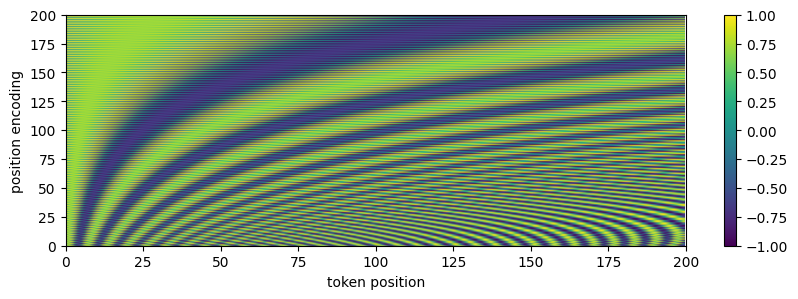

In [3]:
#위치인코딩 만들기(삼각함수 이용)
import numpy as np
import matplotlib.pyplot as plt

d = 500
n_token = 200
pos_encoding = np.zeros((d, n_token))

for p in range(n_token):
    for i in range(0, d, 2):
        pos_encoding[i, p] = np.sin(p/10000**(i/d))
        pos_encoding[i+1, p] = np.cos(p/10000**(i/d))

plt.figure(figsize=(10, 3))
plt.imshow(pos_encoding, interpolation="quadric", aspect="auto")
plt.axis([0, n_token, 0, 200])
plt.xlabel('token position')
plt.ylabel('position encoding')
plt.colorbar()
plt.show()

In [4]:
#위치 임베딩 만들기
vocab_size = 10000
embed_dim = 768
max_seq_len = 512

inputs = keras.Input(shape=(None,))
token_embedding = layers.Embedding(vocab_size, embed_dim)(inputs) # 입력 토큰을 토큰 임베딩으로 변환
token_pos = keras.ops.arange(n_token)  # 입력 토큰의 길이만큼 정수 인덱스 생성
pos_embedding = layers.Embedding(max_seq_len, embed_dim)(token_pos)  # 토큰 위치를 위치 임베딩으로 변환
encoder_inputs = token_embedding + pos_embedding  # 토큰 임베딩과 위치 임베딩을 더하여 최종 입력

'''
vocab_size : 어휘 사전 크기
embed_dim : 임베딩의 크기
max_seq_len : 입력 시퀀스의 최대 길이
'''

'\nvocab_size : 어휘 사전 크기\nembed_dim : 임베딩의 크기\nmax_seq_len : 입력 시퀀스의 최대 길이\n'

In [5]:
#층 정규화
data = np.arange(12, dtype="float32").reshape(2, 2, 3)
print(data)

[[[ 0.  1.  2.]
  [ 3.  4.  5.]]

 [[ 6.  7.  8.]
  [ 9. 10. 11.]]]


In [6]:
#샘플데이터 배치정규화 처리
batchnorm = layers.BatchNormalization()
print(batchnorm(data, training=True).numpy())

[[[-1.3415811  -1.3415811  -1.3415811 ]
  [-0.44719368 -0.44719374 -0.44719374]]

 [[ 0.44719374  0.44719374  0.44719374]
  [ 1.3415811   1.341581    1.3415812 ]]]


In [7]:
temp = np.array([0, 3, 6, 9])
(temp - np.mean(temp)) / (np.sqrt(np.var(temp) + 1e-3))

array([-1.34158116, -0.44719372,  0.44719372,  1.34158116])

In [8]:
#샘플데이터 층정규화 처리
layernorm = layers.LayerNormalization()
print(layernorm(data).numpy())

[[[-1.2238274  0.         1.2238274]
  [-1.2238274  0.         1.2238274]]

 [[-1.2238274  0.         1.2238274]
  [-1.2238274  0.         1.2238274]]]


In [9]:
temp = np.array([0, 1, 2])
(temp - np.mean(temp)) / (np.sqrt(np.var(temp) + 1e-3))

array([-1.22382734,  0.        ,  1.22382734])

In [10]:
#트랜스포머 인코더 모델 만들기
def transformer_encoder(x, padding_mask, dropout, activation='relu'):
    residual = x
    key_dim = hidden_dim // num_heads

    #멀티헤드어텐션통과
    x = layers.MultiHeadAttention(num_heads, key_dim, dropout=dropout)(
        query=x, value=x, attention_mask=padding_mask)
    x = layers.Dropout(dropout)(x)

    #스킵연결
    x = x + residual
    x = layers.LayerNormalization()(x)
    residual = x

    #위치별 피드 포워드 네트워크
    x = layers.Dense(hidden_dim * 4, activation=activation)(x)
    x = layers.Dense(hidden_dim)(x)
    x = layers.Dropout(dropout)(x)

    #스킵연결
    x = x + residual
    x = layers.LayerNormalization()(x)
    return x

## BERT 구현하기

In [11]:
import keras_nlp

#BERT base
vacab_size = 30522
num_layers = 12
num_heads = 12
hidden_dim = 768
dropout = 0.1
activation = 'gelu'
max_seq_len = 512

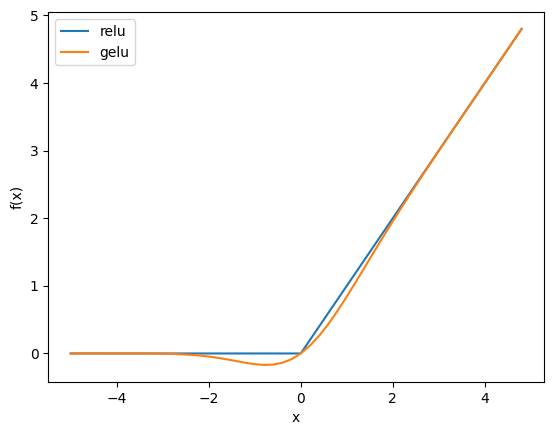

In [12]:
#GELU 함수 그려보기
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

def gelu(x):
    cdf = 0.5 * (1.0 + erf(x/np.sqrt(2.0)))
    return x * cdf

x = np.arange(-5, 5, 0.2)

plt.plot(x, x.clip(0), label='relu')
plt.plot(x, gelu(x), label='gelu')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()

In [13]:
import keras
from keras import layers

token_ids = keras.Input(shape=(None, ))
segment_ids = keras.Input(shape=(None, ))
padding_mask = keras.Input(shape=(None, ))

#토큰 임베딩
token_embedding = layers.Embedding(vocab_size, hidden_dim)(token_ids)
#위치 임베딩
pos_embedding = keras_nlp.layers.PositionEmbedding(max_seq_len)(
    token_embedding)
#세그먼트 임베딩(다음 문장 예측을 위해 입력되는 문장의 개수)
seg_embedding = layers.Embedding(2, hidden_dim)(segment_ids)

In [14]:
#임베딩을 모두 더한 후 층정규화와 드롭아웃 적용
x = layers.Add()((token_embedding, pos_embedding, seg_embedding))
x = layers.LayerNormalization()(x)
x = layers.Dropout(dropout)(x)

In [15]:
#transformer_encoder 반복
for _ in range(num_layers):
    x = transformer_encoder(x, padding_mask, dropout, activation)

In [16]:
outputs = layers.Dense(hidden_dim, activation='tanh')(x[:, 0, :]) #첫번째 토근에 분류 작업에 대한 결과가 저장되어 있음
model = keras.Model(inputs=(token_ids, segment_ids, padding_mask), outputs=(outputs))

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, None, 768) │  7,680,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 768) │    393,216 │ embedding_2[0][0] │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, None, 768) │      1,536 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, None, 768) │          0 │ embedding_2[0][0… │
│                     │                   │            │ position_embeddi… │
│                     │                   │            │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 768) │      1,536 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_4       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, None, 768) │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 768) │  2,362,368 │ input_layer_4[0]… │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, None, 768) │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, None, 768) │          0 │ dropout_3[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 768) │      1,536 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, None,      │  2,362,368 │ layer_normalizat… │
│                     │ 3072)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, None, 768) │  2,360,064 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, None, 768) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, None, 768) │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 93,721,344 (357.52 MB)

 Trainable params: 93,721,344 (357.52 MB)

 Non-trainable params: 0 (0.00 B)

## KerasNLP로 사전훈련된 BERT 불러와 영화 리뷰 텍스트 감성 분류하기

- IMDB(Internet Movie Database) : 영화리뷰데이터셋
- IMDB 사이트의 영화 리뷰를 긍정과 부정의 감정 레이블로 분류해 높은 표준 데이터셋
- 감성분석(sentiment analysis)작업에 많이 활용됨

In [18]:
#IMDB 데이터셋 로드
!gdown 15ZSv_07b3HCKKn08jSDLl4JO4EFy8t-t
!tar -xzf aclImdb_v1.tar.gz

#비지도학습에 사용하는 데이터는 삭제
!rm -r aclImdb/train/unsup

Downloading...
From (original): https://drive.google.com/uc?id=15ZSv_07b3HCKKn08jSDLl4JO4EFy8t-t
From (redirected): https://drive.google.com/uc?id=15ZSv_07b3HCKKn08jSDLl4JO4EFy8t-t&confirm=t&uuid=7cd63e98-99b4-43be-8c9d-f542c4c53c69
To: /content/aclImdb_v1.tar.gz
100% 84.1M/84.1M [00:01<00:00, 47.4MB/s]


In [19]:
#텍스트 데이터로 읽어들이기
train_ds, val_ds = keras.utils.text_dataset_from_directory(
    'aclImdb/train', subset='both', validation_split=0.2, seed=42)
test_ds = keras.utils.text_dataset_from_directory('aclImdb/test')

Found 25000 files belonging to 2 classes.
Using 20000 files for training.
Using 5000 files for validation.
Found 25000 files belonging to 2 classes.


In [20]:
#샘플 하나 추출
feature, target = train_ds.unbatch().take(1).get_single_element()
print(feature.numpy()[:100])
print(target.numpy())

b'"Pandemonium" is a horror movie spoof that comes off more stupid than funny. Believe me when I tell '
0


부정적일때 0, 긍정적일때 1

In [21]:
#사전훈련된 BERT 모델 로드
classifier = keras_nlp.models.BertClassifier.from_preset("bert_tiny_en_uncased", num_classes=2)

#from_preset으로 사전 훈련된 가중치를 포함하여 BERT 모델을 쉽게 구성할 수 있음
#colab의 실행 메모리를 감안해 가장 작은 bert_tiny_en_uncased 모델을 사용
#en = english
#uncased = 모두 소문자 처리한 후 모델 훈련

In [22]:
classifier.summary()

Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 128), (None,      │       4,385,920 │ padding_mask[0][0],        │
│                               │ None, 128)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 128)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │             258 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,386,178 (16.73 MB)

 Trainable params: 4,386,178 (16.73 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#KerasNLP로 모델 훈련시키기
classifier.fit(train_ds, validation_data=val_ds, epochs=5)

#사전훈련된 대규모 언어모델을 사용하여 약간의 훈련으로도 높은 성능을 달성

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2393s 4s/step - loss: 0.5815 - sparse_categorical_accuracy: 0.6793 - val_loss: 0.3579 - val_sparse_categorical_accuracy: 0.8518
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2332s 4s/step - loss: 0.3303 - sparse_categorical_accuracy: 0.8644 - val_loss: 0.3306 - val_sparse_categorical_accuracy: 0.8626
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2361s 4s/step - loss: 0.2697 - sparse_categorical_accuracy: 0.8911 - val_loss: 0.3116 - val_sparse_categorical_accuracy: 0.8730
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2394s 4s/step - loss: 0.2025 - sparse_categorical_accuracy: 0.9248 - val_loss: 0.3509 - val_sparse_categorical_accuracy: 0.8654
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 2324s 4s/step - loss: 0.1543 - sparse_categorical_accuracy: 0.9429 - val_loss: 0.3272 - val_sparse_categorical_accuracy: 0.8810


In [24]:
classifier = keras_nlp.models.BertClassifier.from_preset(
    "bert_tiny_en_uncased", num_classes=1, activation='sigmoid')

In [25]:
#이진분류설정, 옵티마이저:RMSProp
rmsprop = keras.optimizers.RMSprop(learning_rate=0.001)
classifier.compile(loss='binary_crossentropy', optimizer=rmsprop, metrics=["accuracy"])
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
hist = classifier.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=[early_stopping_cb])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2329s 4s/step - accuracy: 0.6136 - loss: 0.6234 - val_accuracy: 0.7894 - val_loss: 0.4528
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2352s 4s/step - accuracy: 0.8064 - loss: 0.4386 - val_accuracy: 0.8280 - val_loss: 0.3965
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2313s 4s/step - accuracy: 0.8479 - loss: 0.3616 - val_accuracy: 0.8374 - val_loss: 0.3858
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2349s 4s/step - accuracy: 0.8643 - loss: 0.3317 - val_accuracy: 0.8724 - val_loss: 0.3058
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2294s 4s/step - accuracy: 0.8865 - loss: 0.2903 - val_accuracy: 0.8682 - val_loss: 0.3653
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2361s 4s/step - accuracy: 0.9141 - loss: 0.2421 - val_accuracy: 0.8806 - val_loss: 0.3055
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2354s 4s/step - accuracy: 0.9256 - loss: 0.2062 - val_accuracy: 0.6970 - val_loss: 0.6531
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2316s 4s/step - accuracy: 0.9371 - loss: 0.1821 - 

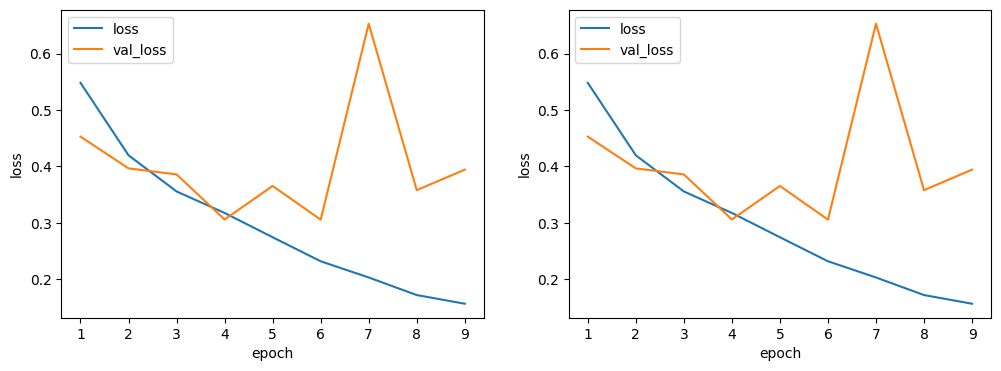

In [26]:
#모델성능시각화
epochs = np.array(hist.epoch)+1
fig,axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(epochs, hist.history['loss'], label='loss')
axs[0].plot(epochs, hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(epochs)
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()
axs[1].plot(epochs, hist.history['loss'], label='loss')
axs[1].plot(epochs, hist.history['val_loss'], label='val_loss')
axs[1].set_xticks(epochs)
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('loss')
axs[1].legend()
plt.show()

In [27]:
#샘플 예측
classifier.predict([feature])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.17155862]], dtype=float32)

In [28]:
classifier.evaluate(test_ds)

782/782 ━━━━━━━━━━━━━━━━━━━━ 884s 1s/step - accuracy: 0.8744 - loss: 0.3271


[0.33245593309402466, 0.8706799745559692]

## 텍스트 전처리

In [29]:
prep_data = classifier.preprocessor(feature)
print(len(prep_data['token_ids']), prep_data['token_ids'][:10])

512 tf.Tensor([  101  1000  6090  3207 26387  1000  2003  1037  5469  3185], shape=(10,), dtype=int32)


In [30]:
prep_data['token_ids'][-10:]

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)>

In [31]:
sum(prep_data['padding_mask'].numpy())

np.int64(197)

In [32]:
bert_tokenizer = classifier.preprocessor.tokenizer
bert_tokenizer.detokenize(prep_data['token_ids'][:10])

'[CLS] " pandemonium " is a horror movie'

In [33]:
tokens=[]
for id in prep_data['token_ids'][:10]:
    tokens.append(bert_tokenizer.id_to_token(id))
print(tokens)

['[CLS]', '"', 'pan', '##de', '##monium', '"', 'is', 'a', 'horror', 'movie']


In [34]:
#토큰을 토큰 아이디로 변환
for token in tokens:
    print(bert_tokenizer.token_to_id(token), end=' ')

101 1000 6090 3207 26387 1000 2003 1037 5469 3185 

## 허깅페이스로 영화리뷰텍스트의 감성 분류하기
- 네이버 영화 리뷰 데이터에서 전이학습 수행

In [35]:
#실습에 필요한 라이브러리 설치
!pip install datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00


In [36]:
from datasets import load_dataset

nsmc = load_dataset("nsmc", trust_remote_code=True)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nsmc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'nsmc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of yo

README.md: 0.00B [00:00, ?B/s]

nsmc.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found nsmc.py

In [37]:
print(nsmc)

NameError: name 'nsmc' is not defined

In [38]:
import pandas as pd

train_df = pd.read_table("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
test_df = pd.read_table("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")

In [39]:
from datasets import Dataset, DatasetDict

# NaN이 있는 행 제거 (Hugging Face는 NaN 허용 안 함)
train_df = train_df.dropna()
test_df = test_df.dropna()

# Dataset으로 변환 (index 컬럼 제거)
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))


# 딕셔너리처럼 묶기
nsmc = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

In [40]:
nsmc['train'][1]

{'id': 3819312, 'document': '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나', 'label': 1}

In [41]:
#백본 모델 선택하기
from transformers import AutoModelForSequenceClassification

bert_kor = AutoModelForSequenceClassification.from_pretrained(
    "bongsoo/bert-small-kor-v1", num_labels=2
)

config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/74.2M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bongsoo/bert-small-kor-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
print(bert_kor)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(10022, 512, padding_idx=0)
      (position_embeddings): Embedding(512, 512)
      (token_type_embeddings): Embedding(2, 512)
      (LayerNorm): LayerNorm((512,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=512, out_features=512, bias=True)
              (key): Linear(in_features=512, out_features=512, bias=True)
              (value): Linear(in_features=512, out_features=512, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=512, out_features=512, bias=True)
              (LayerNorm): LayerNorm((512,), eps=1e-1

In [43]:
#토크나이저 불러오기
from transformers import AutoTokenizer

bert_kor_tokenizer = AutoTokenizer.from_pretrained(
    "bongsoo/bert-small-kor-v1")

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/449 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

In [44]:
#토크나이저에 훈련세트 첫번째 샘플 전달하여 텍스트 변환
from transformers import AutoTokenizer

bert_kor_tokenizer = AutoTokenizer.from_pretrained(
    "bongsoo/bert-small-kor-v1")

prep_data = bert_kor_tokenizer(nsmc['train'][0]['document'])
prep_data.keys()

KeysView({'input_ids': [2, 606, 261, 1519, 17, 17, 4668, 766, 1400, 1132, 1464, 1130, 2889, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]})

In [45]:
prep_data['input_ids']

[2, 606, 261, 1519, 17, 17, 4668, 766, 1400, 1132, 1464, 1130, 2889, 3]

In [46]:
tokens= bert_kor_tokenizer.convert_ids_to_tokens(prep_data['input_ids'])
print(tokens)

['[CLS]', '아', '더', '##빙', '.', '.', '진짜', '짜', '##증', '##나', '##네', '##요', '목소리', '[SEP]']


- [CLS] : 분류에 사용하는 특수 토큰
- [SEP] : 다음 문장 예측에서 두 문장을 구분하는 특수 토큰

In [47]:
#원본 문자열 변환
bert_kor_tokenizer.convert_tokens_to_string(tokens)

'[CLS] 아 더빙.. 진짜 짜증나네요 목소리 [SEP]'

In [48]:
#document 속성에 있는 문자열을 전처리하는 함수 정의
def tokenize(batch):
    return bert_kor_tokenizer(batch['document'], padding="max_length", truncation=True, max_length=128)

In [49]:
#nsmc 데이터셋 토큰화
nsmc_tokenized = nsmc.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/149995 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/74.2M [00:00<?, ?B/s]

Map:   0%|          | 0/49997 [00:00<?, ? examples/s]

In [50]:
print(nsmc_tokenized)

DatasetDict({
    train: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 149995
    })
    test: Dataset({
        features: ['id', 'document', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 49997
    })
})


In [51]:
#훈련 샘플 일부만 활용
nsmc_train = nsmc_tokenized['train'].shuffle(seed=42).select(range(1000))
nsmc_test = nsmc_tokenized['test'].shuffle(seed=42).select(range(100))

In [52]:
#BERT 모델 fine tuning
import evaluate

metric = evaluate.load("accuracy")

import numpy as np

def compute_metrics(eval_pred):  #훈련과정에서 에포크가 끝날 때마다 검증 데이터셋의 정확도를 계산하기 위해 호출됨
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)  #모델의 정확도 계산

In [53]:
from transformers import TrainingArguments

training_args = TrainingArguments(output_dir='bert_kor_nsmc',
                                  num_train_epochs=5,
                                  eval_strategy='epoch',
                                  save_strategy='epoch',
                                  logging_steps=len(nsmc_train)//8,
                                  load_best_model_at_end=True,
                                  report_to="none")

In [56]:
from transformers import Trainer

trainer = Trainer(model=bert_kor,
                  train_dataset=nsmc_train,
                  eval_dataset=nsmc_test,
                  args=training_args,
                  compute_metrics=compute_metrics)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.608000,0.513915,0.770000
2,0.426600,0.528651,0.780000
3,0.261700,0.594424,0.830000
4,0.167600,0.685278,0.810000
5,0.107700,0.691983,0.800000


TrainOutput(global_step=625, training_loss=0.3143026931762695, metrics={'train_runtime': 1297.758, 'train_samples_per_second': 3.853, 'train_steps_per_second': 0.482, 'total_flos': 49437089280000.0, 'train_loss': 0.3143026931762695, 'epoch': 5.0})

In [57]:
#사전 훈련된 BERT 모델로 예측하기
preds_output = trainer.predict(nsmc_test)

print(preds_output.predictions[:7])
print(preds_output.label_ids[:7])

[[-0.14003322 -0.6599534 ]
 [ 0.11801139 -0.6289506 ]
 [-0.08081342  0.04795257]
 [ 0.39230254 -0.71158814]
 [ 0.14757589 -0.771199  ]
 [-1.00548     0.2813628 ]
 [-0.4140078  -0.20647344]]
[0 0 1 1 0 0 0]


In [63]:
#미세튜닝된 모델 허깅페이스에서 가져와서 분석하기
from transformers import pipeline

pipe = pipeline(task='text-classification', device=0,
                model='WhitePeak/bert-base-cased-Korean-sentiment')

config.json:   0%|          | 0.00/895 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/711M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


In [64]:
pipe('아 더빙.. 진짜 짜증나네요 목소리')

[{'label': 'LABEL_0', 'score': 0.997101366519928}]